In [1]:
from typing import List, Tuple, Dict, Union

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display, Markdown
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC, SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE # Source: https://imbalanced-learn.org/stable/over_sampling.html

import src.utils.utils as ut

In [2]:
wine_df = pd.read_csv(ut.get_project_file_path("src", "data", "transformed", "wines_clean.csv"))
wine_df = wine_df.reset_index(drop=False,)
wine_df = wine_df.rename(columns={"index": "wine_id"})
wine_df.head(3)

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,San Carlos,San Juan,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores
0,0,https://www.vivino.com/US/en/luigi-bosca-parai...,Paraiso,2020.0,Luigi Bosca,4.8,582.0,188.33,0.7343,0.5090,...,0,0,0,0,0,0,0,0,0,0
1,1,https://www.vivino.com/US/en/catena-zapata-est...,Estiba Reservada,2015.0,Catena Zapata,4.7,297.0,675.00,0.7417,0.5583,...,0,0,0,0,0,0,0,0,0,0
2,2,https://www.vivino.com/US/en/catena-zapata-est...,Estiba Reservada,2017.0,Catena Zapata,4.7,219.0,580.00,0.7417,0.5583,...,0,0,0,0,0,0,0,0,0,0


In [3]:
users_data_complete = pd.read_pickle(ut.get_project_file_path("src", "data", "synthetic", "simulation_06_0.008_0.4_n400_repchs.pkl"))
users_data = users_data_complete.dropna()
users_data.head(3)

,event_timestamp,user_id,wine_id,user_input,metrics_local,metrics_global,liked,prob_like
0,2022-08-08,0,1253.0,"{'meal': 'Pasta con Salsa Mixta', 'main_pairin...",rating_rscld 1.0 price_rscld ...,rating_rscld_gbl 1.0 price_rscl...,1.0,0.939337
1,2022-09-08,0,1535.0,"{'meal': 'Empanadas de Carne', 'main_pairing':...",rating_rscld 0.0 price_rscld ...,rating_rscld_gbl 0.333333 price_rscl...,1.0,0.981385
2,2022-10-05,0,1898.0,"{'meal': 'Ensalada', 'main_pairing': 'vegetari...",rating_rscld 0.0 price_rscld ...,rating_rscld_gbl -0.333333 price_rscl...,1.0,0.826939


In [4]:
recommend_df = pd.merge(wine_df, users_data, how="inner", on="wine_id")
recommend_df.head(3)

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,Uco Valley,Vale dos Vinhedos,Vista Flores,event_timestamp,user_id,user_input,metrics_local,metrics_global,liked,prob_like
0,0,https://www.vivino.com/US/en/luigi-bosca-parai...,Paraiso,2020.0,Luigi Bosca,4.8,582.0,188.33,0.7343,0.5090,...,0,0,0,2023-02-28,247,"{'meal': 'Pollo al Horno con Papas', 'main_pai...",rating_rscld 2.5 price_rscld ...,rating_rscld_gbl 2.666667 price_rscl...,1.0,0.727985
1,10,https://www.vivino.com/US/en/catena-zapata-nic...,Nicolás Catena Zapata,2017.0,Catena Zapata,4.6,3783.0,246.74,0.7443,0.4805,...,0,0,0,2023-12-19,191,"{'meal': 'Ciervo Estofado', 'main_pairing': 'g...",rating_rscld 0.823529 price_rscld ...,rating_rscld_gbl 2.0 price_rscl...,0.0,0.834378
2,60,https://www.vivino.com/finca-decero-amano-remo...,Amano Remolinos Vineyard,2018.0,Finca Decero,4.5,36.0,69.99,0.6567,0.4423,...,0,0,0,2022-12-26,68,"{'meal': 'Carne con Salsa de Champiñones', 'ma...",rating_rscld 1.0 price_rscld ...,rating_rscld_gbl 1.666667 price_rscl...,1.0,0.947827


In [5]:
grapes = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "grapes.csv"))
grapes_list = list(grapes["grapes"])
region = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "region.csv"))
region_list = list(region["region"])
pairings = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "pairings.csv"))
pairings_list = list(pairings["pairings"])

In [6]:
recommend_df["user_main_pairing"] = recommend_df["user_input"].apply(lambda x: x["main_pairing"])
recommend_df["has_user_main_pairing"] = recommend_df.apply(lambda row: 1 if row[row["user_main_pairing"]]==1 else 0, axis=1)

taste_list = ["body", "tannins", "sweetness", "acidity"]
for taste in taste_list:
    recommend_df["user_" + taste + "_min"] = recommend_df["user_input"].apply(lambda x: x["tastes"][taste][0])
    recommend_df["user_" + taste + "_max"] = recommend_df["user_input"].apply(lambda x: x["tastes"][taste][1])

recommend_df["user_taste_distance_raw"] = recommend_df["metrics_global"].apply(lambda x: x["taste_distance_raw_gbl"])
recommend_df.head(3)

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,has_user_main_pairing,user_body_min,user_body_max,user_tannins_min,user_tannins_max,user_sweetness_min,user_sweetness_max,user_acidity_min,user_acidity_max,user_taste_distance_raw
0,0,https://www.vivino.com/US/en/luigi-bosca-parai...,Paraiso,2020.0,Luigi Bosca,4.8,582.0,188.33,0.7343,0.5090,...,1,0.691752,0.766131,0.333468,0.570218,0.342750,0.456097,0.041018,0.468561,0.316204
1,10,https://www.vivino.com/US/en/catena-zapata-nic...,Nicolás Catena Zapata,2017.0,Catena Zapata,4.6,3783.0,246.74,0.7443,0.4805,...,1,0.698832,0.849526,0.582728,1.000000,0.294021,0.370115,0.578115,1.000000,0.069595
2,60,https://www.vivino.com/finca-decero-amano-remo...,Amano Remolinos Vineyard,2018.0,Finca Decero,4.5,36.0,69.99,0.6567,0.4423,...,1,0.204380,0.649635,0.600484,1.000000,0.495763,1.000000,0.523209,1.000000,0.089373


In [7]:
grapes = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "grapes.csv"))
grapes_list = list(grapes["grapes"])
region = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "region.csv"))
region_list = list(region["region"])
pairings = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "pairings.csv"))
pairings_list = list(pairings["pairings"])

model_df = recommend_df.drop(columns=[
    "event_timestamp", "wine_id", "wine_link", "name", "winery", "style", "image",                                  # Original df columns
    "user_id", "user_input", "metrics_local", "metrics_global", "prob_like", "user_main_pairing" # User data columns
]).copy()      

model_df_nooh = model_df.drop(columns=(grapes_list + region_list)).copy() # One-hot columns

model_df_nocat = model_df_nooh.drop(columns=pairings_list) # Categorical column

print(model_df.columns, "\n", model_df_nooh.columns, "\n", model_df_nocat.columns)

Index(['year', 'rating', 'rating_qty', 'price', 'body', 'tannins', 'sweetness',
       'acidity', 'alcohol', 'ageing',
       ...
       'has_user_main_pairing', 'user_body_min', 'user_body_max',
       'user_tannins_min', 'user_tannins_max', 'user_sweetness_min',
       'user_sweetness_max', 'user_acidity_min', 'user_acidity_max',
       'user_taste_distance_raw'],
      dtype='object', length=124) 
 Index(['year', 'rating', 'rating_qty', 'price', 'body', 'tannins', 'sweetness',
       'acidity', 'alcohol', 'ageing', 'black fruit', 'citrus', 'dried fruit',
       'earthy', 'floral', 'oaky', 'red fruit', 'spices', 'tree fruit',
       'tropical', 'vegetal', 'yeasty', 'any junk food will do', 'aperitif',
       'appetizers and snacks', 'beef', 'blue cheese', 'cured meat',
       'game (deer, venison)', 'goat's milk cheese', 'lamb', 'lean fish',
       'mature and hard cheese', 'mild and soft cheese', 'mushrooms', 'pasta',
       'pork', 'poultry', 'rich fish (salmon, tuna etc)', 'shellf

In [8]:
# Oversamplea el DF con el objeto de oversample que se le de
def oversample_df(
        df: pd.DataFrame,
        sampling_object: object,
        random_state: Union[int, None]=None,
        categorical_features: Union[List[str], None]=None,
        class_col: str = "liked"    
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    
    if sampling_object.__name__ == SMOTENC.__name__:
        sampler = sampling_object(
            categorical_features=categorical_features,
            random_state=random_state
        )
    else:
        sampler = sampling_object(random_state=random_state)

    X = df.drop(columns=[class_col])
    y = df[class_col]

    X_resampled, y_resampled = sampler.fit_resample(X, y)

    return X_resampled, y_resampled

# Splitea, predice y compara test y train
def train_test_model(
        X: Union[pd.Series, pd.DataFrame],
        y: Union[pd.Series, pd.DataFrame],
        model_object: object,
        test_size: float=0.2,
        random_state: Union[int, None]=None,
        stratify: Union[pd.Series, pd.DataFrame, None]=None
    ) -> Dict[str, Union[str, object, float]]:
    
    # Split de datos en train y test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=stratify)
    
    # Entrenamiento
    model_object.fit(X_train, y_train)

    # Predicción de train
    y_train_proba = model_object.predict_proba(X_train)[:, 1]
    y_train_pred = model_object.predict(X_train)
    cm_train = confusion_matrix(y_train, y_train_pred)
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=model_object.classes_)

    # Predicción de test
    y_pred_proba = model_object.predict_proba(X_test)[:, 1]
    y_pred = model_object.predict(X_test)
    cm_pred = confusion_matrix(y_test, y_pred)
    disp_pred = ConfusionMatrixDisplay(confusion_matrix=cm_pred, display_labels=model_object.classes_)

    return {
        "train_report": classification_report(y_train, y_train_pred),
        "train_cmax": disp_train,
        "train_auc": roc_auc_score(y_train, y_train_proba),
        "test_report": classification_report(y_test, y_pred),
        "test_cmax": disp_pred,
        "test_auc": roc_auc_score(y_test, y_pred_proba),
        "X_test": X_test,
        "y_test": y_test
    }    


# Muestra los resultados del modelo
def print_model_results(results: Dict[str, Union[str, object, float]]):
    print("\n----------------------------------------------------\n")
    print("Train Metrics:\n")
    print(results["train_report"])
    results["train_cmax"].plot()
    plt.show()
    print("AUC Train:", results["train_auc"])
    print("\n----------------------------------------------------\n")
    print("Test Metrics:\n")
    print(results["test_report"])
    results["test_cmax"].plot()
    plt.show()
    print("AUC Train:", results["test_auc"])


In [9]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=2, min_samples_leaf=1, max_features="sqrt", class_weight="balanced")

# SMOTENC

# SMOTENC


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.96      0.92      0.94      1725
         1.0       0.93      0.96      0.94      1726

    accuracy                           0.94      3451
   macro avg       0.94      0.94      0.94      3451
weighted avg       0.94      0.94      0.94      3451



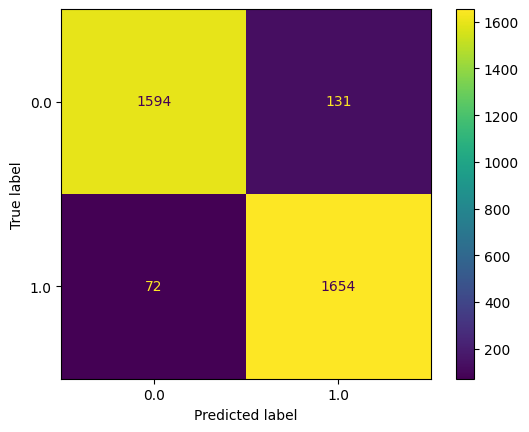

AUC Train: 0.9863056073353821

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.82      0.80      0.81       432
         1.0       0.81      0.82      0.81       431

    accuracy                           0.81       863
   macro avg       0.81      0.81      0.81       863
weighted avg       0.81      0.81      0.81       863



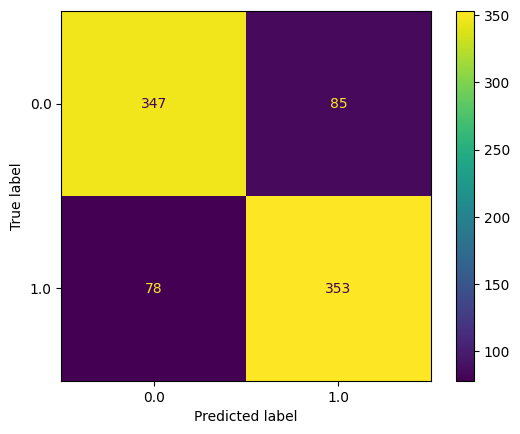

AUC Train: 0.8905216120993383


In [10]:
# SMOTENC para df con categorical features
idx_cat_features = [model_df_nooh.columns.get_loc(col) for col in pairings_list]

X_smotenc, y_smotenc = oversample_df(
    df=model_df_nooh,
    sampling_object=SMOTENC,
    random_state=0,
    categorical_features=idx_cat_features
)

results_smotenc = train_test_model(
    X=X_smotenc,
    y=y_smotenc,
    model_object=rf_model,
    test_size=0.2,
    random_state=0,
    stratify=y_smotenc
)

display(Markdown("# SMOTENC"))
print_model_results(results_smotenc)

# SMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.96      0.94      0.95      1725
         1.0       0.94      0.96      0.95      1726

    accuracy                           0.95      3451
   macro avg       0.95      0.95      0.95      3451
weighted avg       0.95      0.95      0.95      3451



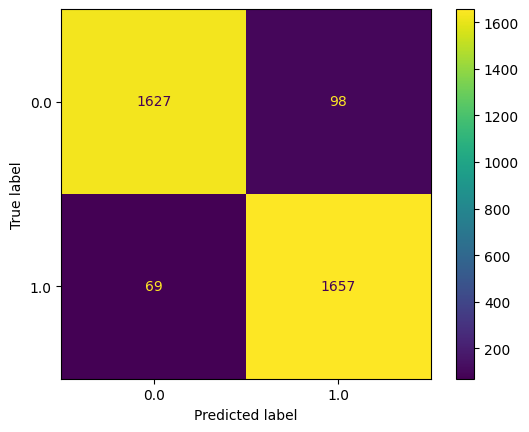

AUC Train: 0.9885129393588258

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.79      0.81      0.80       432
         1.0       0.81      0.79      0.80       431

    accuracy                           0.80       863
   macro avg       0.80      0.80      0.80       863
weighted avg       0.80      0.80      0.80       863



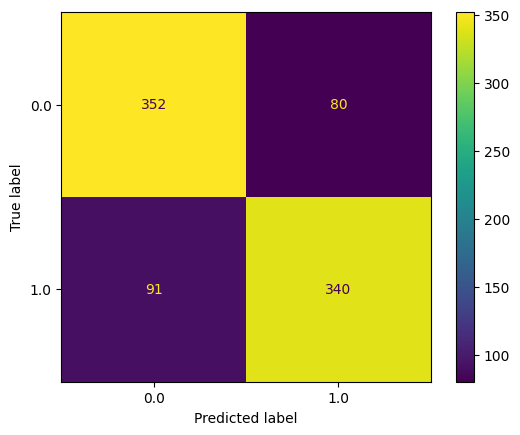

AUC Train: 0.8935507433187246


# ADASYN


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.96      0.95      0.95      1718
         1.0       0.95      0.96      0.96      1726

    accuracy                           0.96      3444
   macro avg       0.96      0.96      0.96      3444
weighted avg       0.96      0.96      0.96      3444



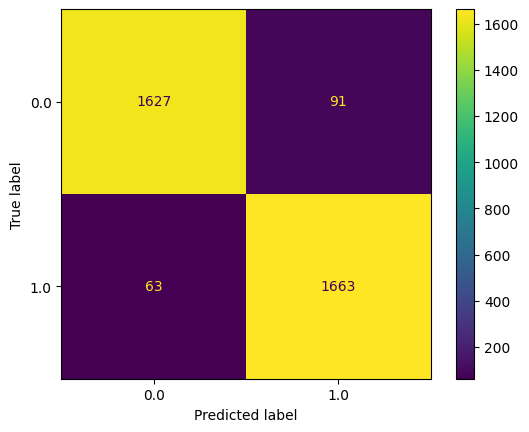

AUC Train: 0.9907886909378848

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.81      0.81      0.81       430
         1.0       0.81      0.81      0.81       431

    accuracy                           0.81       861
   macro avg       0.81      0.81      0.81       861
weighted avg       0.81      0.81      0.81       861



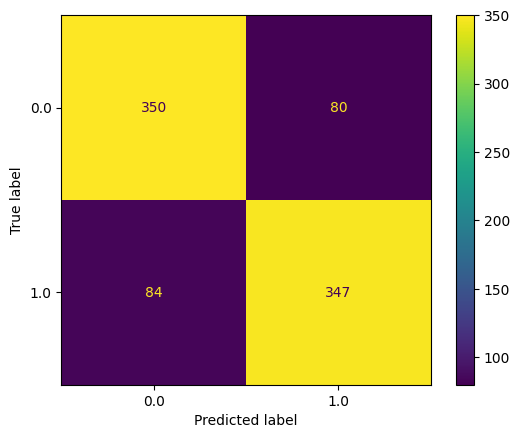

AUC Train: 0.8883559056817569


# BorderlineSMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.96      0.93      0.94      1725
         1.0       0.93      0.96      0.95      1726

    accuracy                           0.94      3451
   macro avg       0.94      0.94      0.94      3451
weighted avg       0.94      0.94      0.94      3451



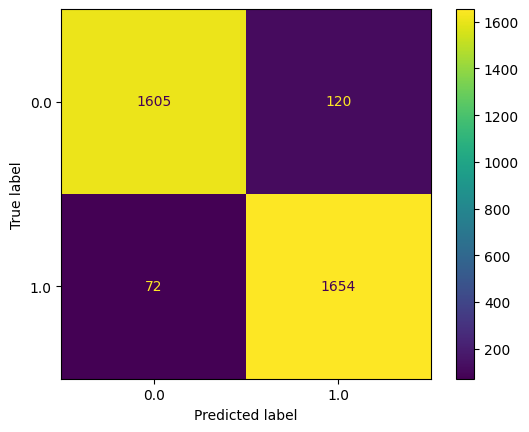

AUC Train: 0.9875013014929382

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.81      0.84      0.82       432
         1.0       0.83      0.81      0.82       431

    accuracy                           0.82       863
   macro avg       0.82      0.82      0.82       863
weighted avg       0.82      0.82      0.82       863



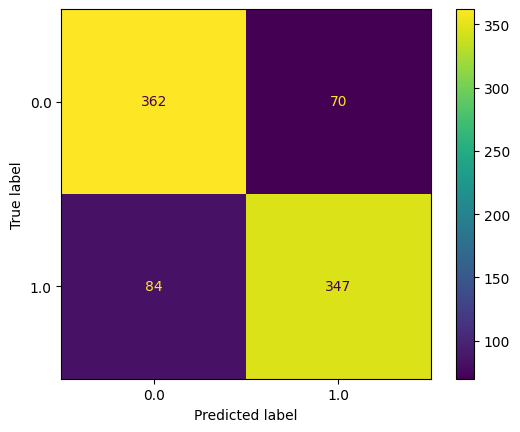

AUC Train: 0.8960374237346396


# SVMSMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.97      0.89      0.93      1725
         1.0       0.90      0.97      0.94      1726

    accuracy                           0.93      3451
   macro avg       0.94      0.93      0.93      3451
weighted avg       0.94      0.93      0.93      3451



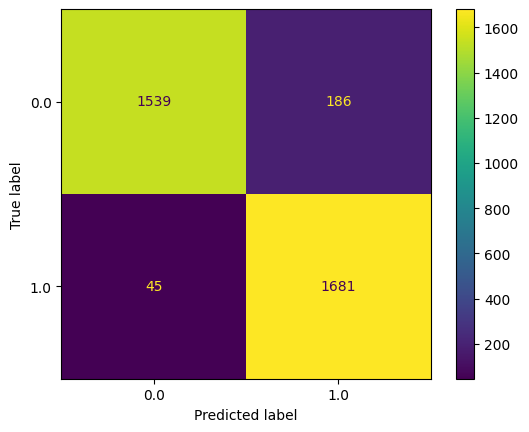

AUC Train: 0.9849668329218936

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.83      0.77      0.80       432
         1.0       0.78      0.85      0.81       431

    accuracy                           0.81       863
   macro avg       0.81      0.81      0.81       863
weighted avg       0.81      0.81      0.81       863



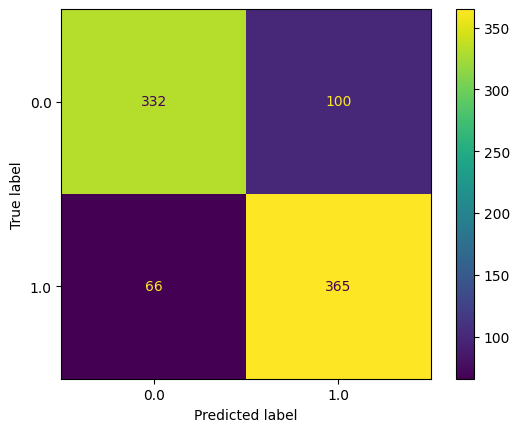

AUC Train: 0.8903712296983758


In [11]:
sampling_objects = [SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE]

for obj in sampling_objects:

    X_resampled, y_resampled = oversample_df(
        df=model_df_nocat,
        sampling_object=obj,
        random_state=0,
    )

    results_resampled = train_test_model(
        X=X_resampled,
        y=y_resampled,
        model_object=rf_model,
        test_size=0.2,
        random_state=0,
        stratify=y_resampled
    )

    display(Markdown(f"# {obj.__name__}"))
    print_model_results(results_resampled)

In [12]:
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 200,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [13]:
 # TODO: luego, calcular el average tenure days, el life time value, LTV proyectado y hacer evaluación económica de los modelos para fine tunning

In [14]:
test_df = users_data_complete.copy()
test_df = test_df.sort_values(by=["user_id", "event_timestamp"])
test_df["last_event"] = test_df.groupby("user_id")["event_timestamp"].shift(1)

In [15]:
test_df["days_btw_purch"] = (test_df["event_timestamp"] - test_df["last_event"]).dt.days
avg_days_between_purchases = test_df.groupby("user_id")["days_btw_purch"].mean().round()
avg_days_between_purchases

user_id
0      28.0
1       NaN
2      32.0
3      32.0
4      32.0
       ... 
395    28.0
396    29.0
397    32.0
398     NaN
399     NaN
Name: days_btw_purch, Length: 400, dtype: float64

In [16]:
activity_days_tbl = test_df.groupby("user_id")["event_timestamp"].agg(["max", "min"])
activity_days_tbl["tenure"] = (activity_days_tbl["max"] - activity_days_tbl["min"]).dt.days
activity_days_tbl["tenure"].mean().round()

np.float64(192.0)

In [17]:
wine_prices_tbl = wine_df[["wine_id", "price"]]
user_purchases_tbl = test_df[["event_timestamp", "user_id", "wine_id"]]

user_purchases_tbl = pd.merge(user_purchases_tbl, wine_prices_tbl, how="left", on="wine_id")
user_ltv = user_purchases_tbl.groupby("user_id")["price"].sum()
avg_user_ltv = user_ltv.mean().round()
avg_user_ltv

np.float64(139.0)

Evaluación económica:
- Cada dislike que identifico correctamente, podría pasarlo a un like (churn del user pasa de dislike a like)
- Cada like que identifico correctamente, capturo todo el beneficio (mantengo churn like)
- Cada dislike que se me pasa, es un usuario que pierdo bastante plata de ltv (churn dislike)
- Cada like que se me pasa, es un usuario que podría perder plata (recomiendo otro vino que podría no gustarle)
    - Churn pasa de like a indefinido entre otro vino like o dislike.

Pero el tema es, cuanto me cuesta un churn? Porque el objetivo final sería asignarle o poder calcular un valor final.

El problema, usuario con like tiene mas chance de volver a comprar y con dislike más chance de churnear. El tema es que no se cuanto más va a comprar o dejar de comprar exactamente...

Pensar bien como hacer esta evaluación...

In [ ]:
# True Positive: gana el Ticket Promedio * la probabilidad de que se quede habiéndole gustado
# LTV / Cant decisiones promedio = LTV por pick (ticket promedio) * (1 - Churn Like)

# True Negative: gana el Ticket Promedio * la mejora entre el churn por haberle gustado * Prob de recomendar bien
# y el churn de no haberle gustado
# LTV / Cant decisiones promedio = LTV por pick (ticket promedio) * ( (1 - Churn Like) * Precisión - (1 - Churn Dislike) )

# False Positive: pierde el Ticket Promedio * la probabilidad que se vaya si no le gustó
# LTV / Cant decisiones promedio = LTV por pick (ticket promedio) * Churn Dislike

# False Negative: pierde el Ticket Promedio * el empeoramiento entre la probabilidad de que se quede
# habiéndole gustado y la probabilidad de que se quede por la probabilidad de hacer una buena recomendación
# de un vino que le guste
# LTV / Cant decisiones promedio = LTV por pick (ticket promedio) * ((1 - Churn Like) * Precisión - (1 - Churn Like)) 

**`TP`**: se recomienda un vino y al usuario le gusta.
- Ganamos la prob de que se quede habiéndole gustado * el ticket promedio.
- Avg Tkt * (1 - Churn Like)

**`TN`**: se evalúa un vino y al saber que al usuario no le gustaría, se le recomienda otro que creemos que le va a gustar más.
- Ganamos la diferencia entre la probabilidad que se quede habiéndole disgustado y la probabilidad que se quede habiéndole gustado, ajustada por qué tan buenas acertadas las recomendaciones positivas que hacemos con el modelo.
- Es como decir: ganamos la mejora en probabilidad de que se quede recomendándole otro vino que es incierto si le va a gustar, pero creemos que si.
- Avg Tkt * ( (1 - Churn Like) * Precision - (1 - Churn Dislike) )

**`FP`**: se recomienda un vino y al usuario no le gusta.
- Perdemos el ticket promedio * la probabilidad que se vaya habiéndole disgustado.
- Avg Tkt * Churn Dislike

**`FN`**: se evalúa un vino y al creer que al usuario no le gustaría, se le recomienda otro que creemos que le va a gustar más.
- Perdemos la diferencia entre la probabilidad que se quede habiéndole gustado un vino y la probabilidad que se quede habiéndole gustado, ajustada por qué tan buenas acertadas las recomendaciones positivas que hacemos con el modelo.
- Es como decir: perdemos el empeoramiento en probabilidad que se quede al pasar de recomendar un vino que le gustaría a un vino que es incierto si le va a gustar, pero creemos que si.
- Avg Tkt * ( (1 - Churn Like) * Precision - (1 - Churn Like))

In [ ]:
 # TODO: terminar de definir estos cálculos de impacto económico de la matriz de decisión.
 # TODO: entender si debería considerar otra métrica además de precisión para medir la prob de cada situación en TN y FN

0.692